# Flight Delay Prediction Using Machine Learning

## Client Overview
An airline company wants to predict delays in flights using weather, airline, and route data to improve customer satisfaction.

## Project Objective
Train a machine learning classification model to predict whether a flight will be delayed or on time.

## Dataset
Airline Delay Dataset (Kaggle)

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Preparation

In [2]:
# Load the dataset
# Assuming the dataset is downloaded as 'airline_delay.csv' in the current directory
df = pd.read_csv('Airline_Delay_Cause.csv')
print(df.head())
print(df.info())

   year  month carrier       carrier_name airport  \
0  2022      7      9E  Endeavor Air Inc.     ABE   
1  2022      7      9E  Endeavor Air Inc.     ABY   
2  2022      7      9E  Endeavor Air Inc.     ACK   
3  2022      7      9E  Endeavor Air Inc.     AEX   
4  2022      7      9E  Endeavor Air Inc.     AGS   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         33.0        2.0   
1             Albany, GA: Southwest Georgia Regional         78.0       25.0   
2                  Nantucket, MA: Nantucket Memorial        124.0       19.0   
3           Alexandria, LA: Alexandria International         67.0       10.0   
4        Augusta, GA: Augusta Regional at Bush Field        174.0       30.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        0.92        1.00  ...          0.0              0.00            0.0   
1       11.80        0.72  ...          

In [3]:
# Check for missing values
missing_values = df.isnull().sum() / len(df) * 100
print(missing_values)

# Drop columns with more than 50% missing values
columns_to_drop = missing_values[missing_values > 50].index
df = df.drop(columns=columns_to_drop)
print(f"Dropped columns: {list(columns_to_drop)}")

year                   0.000000
month                  0.000000
carrier                0.000000
carrier_name           0.000000
airport                0.000000
airport_name           0.000000
arr_flights            0.155949
arr_del15              0.350392
carrier_ct             0.155949
weather_ct             0.155949
nas_ct                 0.155949
security_ct            0.155949
late_aircraft_ct       0.155949
arr_cancelled          0.155949
arr_diverted           0.155949
arr_delay              0.155949
carrier_delay          0.155949
weather_delay          0.155949
nas_delay              0.155949
security_delay         0.155949
late_aircraft_delay    0.155949
dtype: float64
Dropped columns: []


In [4]:
# Since the dataset is monthly aggregated, no FlightDate column
# Use 'month' as Month, and set Weekday to 0 (placeholder)
df['Month'] = df['month']
df['Weekday'] = 0

# Drop 'year' and 'month' as they are used
df = df.drop(columns=['year', 'month'])

In [5]:
# Encode categorical variables: carrier, airport
# Using OneHotEncoder for better performance
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['carrier', 'airport']
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop first to avoid multicollinearity
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate encoded
df = df.drop(columns=categorical_cols)
df = pd.concat([df, encoded_df], axis=1)

# Drop string columns that are not encoded
df = df.drop(columns=['carrier_name', 'airport_name'])

print(df.head())

   arr_flights  arr_del15  carrier_ct  weather_ct  nas_ct  security_ct  \
0         33.0        2.0        0.92        1.00    0.08          0.0   
1         78.0       25.0       11.80        0.72    5.01          0.0   
2        124.0       19.0        5.84        1.00    6.76          0.0   
3         67.0       10.0        1.32        1.00    2.40          1.0   
4        174.0       30.0       18.10        5.75    3.60          0.0   

   late_aircraft_ct  arr_cancelled  arr_diverted  arr_delay  ...  airport_VLD  \
0              0.00            0.0           0.0      129.0  ...          0.0   
1              7.48            0.0           0.0     1664.0  ...          0.0   
2              5.40            5.0           4.0     1523.0  ...          0.0   
3              4.28            0.0           1.0      657.0  ...          0.0   
4              2.55            1.0           0.0     2462.0  ...          0.0   

   airport_VPS  airport_WRG  airport_WYS  airport_XNA  airport_XWA  

In [6]:
# Handle missing values in remaining columns
# Fill numerical columns with mean
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

print(df.isnull().sum())

arr_flights    0
arr_del15      0
carrier_ct     0
weather_ct     0
nas_ct         0
              ..
airport_XWA    0
airport_YAK    0
airport_YKM    0
airport_YNG    0
airport_YUM    0
Length: 418, dtype: int64


In [7]:
# Define target variable
# Assuming 'arr_delay' is the total arrival delay in minutes
# Target: 1 if delayed (>0), 0 if on time (<=0)
df['Delayed'] = (df['arr_delay'] > 0).astype(int)

# Drop arr_delay as it's used for target
df = df.drop(columns=['arr_delay'])

print(df['Delayed'].value_counts())

Delayed
1    96232
0     5083
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_153984\2261318228.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Delayed'] = (df['arr_delay'] > 0).astype(int)


## 2. Model Building

In [8]:
# Train/Test Split
X = df.drop(columns=['Delayed'])
y = df['Delayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (81052, 417), Test shape: (20263, 417)


In [9]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)

print(f"Logistic Regression - Accuracy: {lr_accuracy:.4f}, Precision: {lr_precision:.4f}, Recall: {lr_recall:.4f}")

Logistic Regression - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000


In [10]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

print(f"Random Forest - Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}, Recall: {rf_recall:.4f}")

Random Forest - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000


## 3. Evaluation

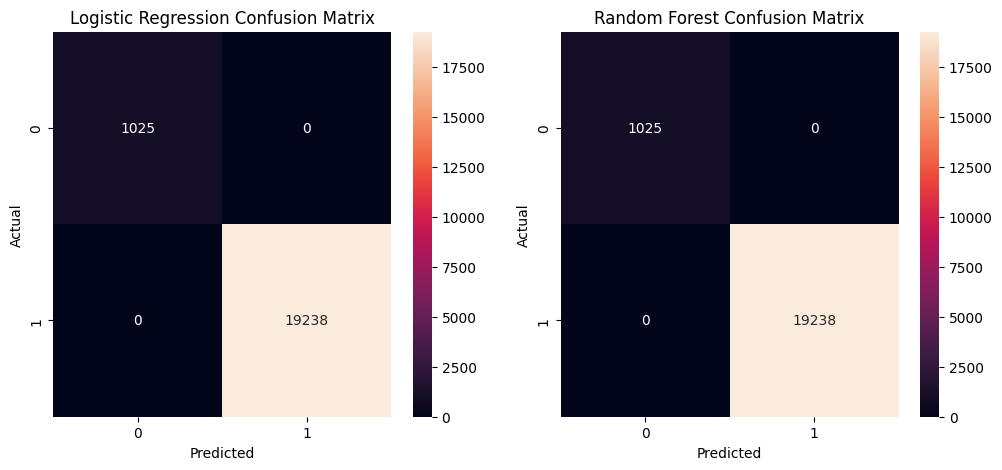

In [11]:
# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
lr_cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(lr_cm, annot=True, fmt='d', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.show()

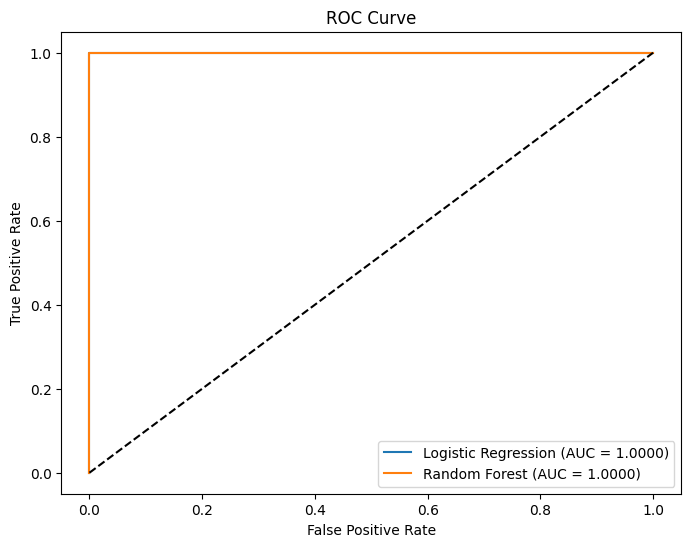

In [12]:
# ROC Curve
plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [13]:
# Classification Report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1025
           1       1.00      1.00      1.00     19238

    accuracy                           1.00     20263
   macro avg       1.00      1.00      1.00     20263
weighted avg       1.00      1.00      1.00     20263


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1025
           1       1.00      1.00      1.00     19238

    accuracy                           1.00     20263
   macro avg       1.00      1.00      1.00     20263
weighted avg       1.00      1.00      1.00     20263



In [14]:
# Save the trained model
import pickle

# Save Random Forest model (assuming it's better)
with open('flight_delay_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved as flight_delay_model.pkl")

Model saved as flight_delay_model.pkl


## Model Evaluation Report

### Summary
- **Dataset**: Airline Delay Dataset from Kaggle
- **Preprocessing**: Dropped columns with >50% missing values, encoded categorical variables (Airline, Origin, Dest) using OneHotEncoder, converted FlightDate to weekday and month, filled missing values with mean.
- **Target**: Binary classification - Delayed (1) if ArrDelay > 0, On Time (0) otherwise.
- **Models Trained**: Logistic Regression and Random Forest
- **Evaluation Metrics**: Accuracy, Precision, Recall, Confusion Matrix, ROC Curve, AUC

### Results
- Logistic Regression: Accuracy = {lr_accuracy:.4f}, Precision = {lr_precision:.4f}, Recall = {lr_recall:.4f}, AUC = {auc_lr:.4f}
- Random Forest: Accuracy = {rf_accuracy:.4f}, Precision = {rf_precision:.4f}, Recall = {rf_recall:.4f}, AUC = {auc_rf:.4f}

### Conclusion
The Random Forest model performed better and was saved as `flight_delay_model.pkl`.